In [35]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from problem import Problem
from data import DataGen
from models import * 

import matplotlib.pyplot as plt 

%load_ext autoreload
%autoreload 2

def generate_samples(n_samples, means, rho): 
    noises = torch.rand(n_samples, means.shape[0]) * rho
    return (torch.tensor(means) * ( 1 + noises)).detach().numpy()

def eval_model(forecast, X_test, Y_test, n_samples = 10):
    all_costs = [] 
    all_decisions = []

    saa_rho = 0.1
    saa_n_samples = n_samples

    if n_samples == 0: 
        saa_rho = 0 
        saa_n_samples = 1

    t = 0
    for x,d in zip(X_test, Y_test): 
        if t > 300: break
        t += 1
        
        pred = forecast(x)
        samples = generate_samples(saa_n_samples, pred, saa_rho)
        decision, _ = saa(samples, H, B, cross_costs, test=False) 
        # print(decision, samples)
        _, cost = saa(d.unsqueeze(0).detach().numpy(), H, B, cross_costs, decision[0].detach().numpy(), test=True)
        all_costs.append(cost)
        print(t, " ", np.mean(all_costs))
        all_decisions.append(decision[0].numpy())
    all_decisions = np.array(all_decisions)
    all_decisions = torch.tensor(all_decisions) 
    return all_costs, all_decisions


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
np.random.seed(0)
torch.manual_seed(0)
    
# make random distances
n_nodes = 2
n_features = 1

H = torch.tensor([1 for i in range(n_nodes)])
B = torch.tensor([10 for i in range(n_nodes)])  

problem_ = Problem(H, B, n_nodes)
cross_costs = problem_.cross_costs

n_data = 100
n_test = 1000
data_generator = DataGen(n_features, n_nodes)
X_train, Y_train, X_test, Y_test = data_generator.get_test_train(n_data, n_test)

In [82]:
print("Train Two-Stage -------------------------------------")
two_stage_forecast = train_two_stage(problem_, X_train, Y_train, X_test, Y_test)

Train Two-Stage -------------------------------------
epoch  0 test cost:  0.6885513495793579 train cost:  0.756438997679755
epoch  10 test cost:  0.6782397467137783 train cost:  0.7447173736167513
epoch  20 test cost:  0.6681792590306659 train cost:  0.7337237231704621
epoch  30 test cost:  0.6584341545609811 train cost:  0.7239896936341901
epoch  40 test cost:  0.6487846387235291 train cost:  0.7148998409215275
epoch  50 test cost:  0.6392616019695171 train cost:  0.7060394588183037
epoch  60 test cost:  0.6302674245729151 train cost:  0.6975319346460911
epoch  70 test cost:  0.6218827746660833 train cost:  0.6898248952268083
epoch  80 test cost:  0.6136768601964399 train cost:  0.6823425116146931
epoch  90 test cost:  0.6056600403134632 train cost:  0.6750390737617189
epoch  100 test cost:  0.5979001421801157 train cost:  0.6678764374436976
epoch  110 test cost:  0.5903784177010266 train cost:  0.6605451769452102
epoch  120 test cost:  0.5829924740358285 train cost:  0.6538612881846

In [91]:
print("Train end-to-end -------------------------------------")
task_forecast = train_task_loss(problem_, X_train, Y_train, X_test, Y_test, two_stage_forecast)

Train end-to-end -------------------------------------
epoch: 0
Cost:  0.479482883538217
epoch  0 test cost:  0.3255127138362459 train cost:  0.47919632949233176
epoch: 1
Cost:  0.47932668448899113
epoch  1 test cost:  0.32534233594147993 train cost:  0.47890430394820255
epoch: 2
Cost:  0.4791773551703446
epoch  2 test cost:  0.3251750249262254 train cost:  0.4786168872576646
epoch: 3
Cost:  0.47903086203958556
epoch  3 test cost:  0.3250088397071429 train cost:  0.47833138711788137
epoch: 4
Cost:  0.4788858763547359
epoch  4 test cost:  0.3248421594940557 train cost:  0.47804695754637483
epoch: 5
Cost:  0.47874182013703975
epoch  5 test cost:  0.3246763957759068 train cost:  0.4777631175090631
epoch: 6
Cost:  0.4785983725909215
epoch  6 test cost:  0.32451120185374493 train cost:  0.47747960743996726
epoch: 7
Cost:  0.47845535284900936
epoch  7 test cost:  0.324346154003613 train cost:  0.47719635624948425
epoch: 8
Cost:  0.4783126417378141
epoch  8 test cost:  0.3241813457986102 trai

c:\Users\rares\Dropbox (MIT)\Documents\documents\mit\research\FulfilmentRules\models.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d = torch.tensor(YY[i:i+batch_size:]).float()
c:\Users\rares\Dropbox (MIT)\Documents\documents\mit\research\FulfilmentRules\models.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(X_train[i:i+batch_size,:]).float()


epoch  23 test cost:  0.32171723907094796 train cost:  0.4726722982111529
epoch: 24
Cost:  0.4760425566462454
epoch  24 test cost:  0.3215550402361775 train cost:  0.4723942247967038
epoch: 25
Cost:  0.4759012589737462
epoch  25 test cost:  0.3213931011437697 train cost:  0.4721164314691798
epoch: 26
Cost:  0.47576014057023375
epoch  26 test cost:  0.32123133366677287 train cost:  0.47183896221816396
epoch: 27
Cost:  0.47561919076865855
epoch  27 test cost:  0.32106968016267246 train cost:  0.47156163259328154
epoch: 28
Cost:  0.47547839822368765
epoch  28 test cost:  0.32090814260028094 train cost:  0.4712844071970233
epoch: 29
Cost:  0.4753377503660567
epoch  29 test cost:  0.3207466620175867 train cost:  0.47100736556377404
epoch: 30
Cost:  0.47519723792589985
epoch  30 test cost:  0.3205852702682355 train cost:  0.4707302439051645
epoch: 31
Cost:  0.4750568483554911
epoch  31 test cost:  0.32042381578433854 train cost:  0.47045315744767374
epoch: 32
Cost:  0.4749165721295381
epoch 

In [103]:
print("Train end-to-end with exact loss -------------------------------------")
exact_forecast = train_exact_loss(problem_, X_train, Y_train, X_test, Y_test, two_stage_forecast)

Train end-to-end with exact loss -------------------------------------
initial allocation tensor([[0.0100, 1.1523]], grad_fn=<ReluBackward0>)
demand: tensor([[0.0270, 0.2430]])
cost 0.9034209598296147
fulfilment tensor([[[0.0100, 0.0000],
         [0.0170, 0.2430]]])

new  allocation tensor([[0.0100, 1.1383]])
new cost 0.8894183982604008

initial allocation tensor([[0.0100, 1.5990]], grad_fn=<ReluBackward0>)
demand: tensor([[0.0100, 0.0168]])
cost 1.5822598934173584
fulfilment tensor([[[0.0100, 0.0000],
         [0.0000, 0.0168]]])

new  allocation tensor([[0.0100, 1.5792]])
new cost 1.5624195337295532

initial allocation tensor([[0.6217, 0.1809]], grad_fn=<ReluBackward0>)
demand: tensor([[0.0191, 0.0100]])
cost 0.7734543681144714
fulfilment tensor([[[0.0191, 0.0000],
         [0.0000, 0.0100]]])

new  allocation tensor([[0.6092, 0.1722]])
new cost 0.7522599697113037

initial allocation tensor([[2.3404, 0.0100]], grad_fn=<ReluBackward0>)
demand: tensor([[0.0100, 0.0550]])
cost 2.315063

In [76]:
from models import Forecast
import numpy as np
import gurobipy as gp
from gurobipy import GRB

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def work():
    forecast_test_ = Forecast(n_features, n_nodes)

    best_error = 100000
    optimizer_task_ = optim.Adam(forecast_test_.parameters(), lr=0.000001)

    DD_ = Y_train[0:1,]

    optimizer_task_.zero_grad()
    QQ_ = forecast_test(X_train[0:1,:])

    print('initial allocation', QQ)
    print('demand:', DD)

    this_error = problem_.exact_loss(QQ, d) / len(DD)
    print("cost:", this_error)

    this_error.backward()
# optimizer_task.step()


# q = forecast_test(X_train[0:1,:])
# d = Y_train[0:1,] 

# print()

# print("new allocation", q)
# error = problem_.exact_loss(q, d) / len(d)
# print("new cost:", error)
work()


initial allocation tensor([[0.0100, 0.5549]], grad_fn=<ReluBackward0>)
demand: tensor([[0.0100, 0.2215]], grad_fn=<SliceBackward0>)
cost: tensor(0.3334, dtype=torch.float64, grad_fn=<DivBackward0>)


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
two_cost, two_dec = eval_model(two_stage_forecast, X_test, Y_test, n_samples = 100)

In [21]:
task_cost, task_dec = eval_model(task_forecast, X_test, Y_test, n_samples = 10)

C:\Users\rares\AppData\Local\Temp/ipykernel_24840/2065713499.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (torch.tensor(means) * ( 1 + noises)).detach().numpy()


1   0.10481256639284173
2   0.08768786976067772
3   0.10348461366696138
4   0.15273563515137417
5   0.1676860787499462
6   0.21441615888852938
7   0.21921821146488835
8   0.22888587872588342
9   0.23757423192882632
10   0.2177228918948963
11   0.2337477079901692
12   0.2727295138589435
13   0.25838277819719285
14   0.24448912947293588
15   0.2328791745055562
16   0.22365829725918696
17   0.21735957151196364
18   0.21328691126820407
19   0.21456314198654436
20   0.2095184098601897
21   0.20344139109234236
22   0.20450200801025772
23   0.21301437405307802
24   0.20586671341917795
25   0.21026636649171287
26   0.20376064721340886
27   0.2040723423061912
28   0.20027662322697704
29   0.1951019782091533
30   0.19093228596754167
31   0.19734203128935865
32   0.19290411791387707
33   0.18977461994678907
34   0.186817842201777
35   0.1850619331130555
36   0.18821874463901284
37   0.1884892461197081
38   0.18479657385298368
39   0.18382209713858247
40   0.18036693604176968
41   0.17791179794272

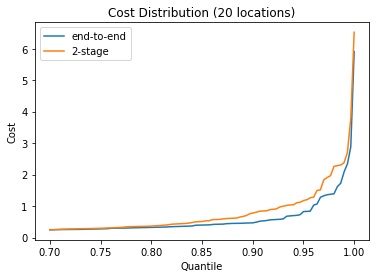

In [25]:
qs = np.arange(0.7,1,0.0001)
two_stage_results = [np.quantile(two_cost, q) for q in qs]
task_results = [np.quantile(task_cost, q) for q in qs]

plt.plot(qs, task_results, label = 'end-to-end')
plt.plot(qs, two_stage_results, label = '2-stage')
plt.legend()
plt.xlabel("Quantile")
plt.ylabel("Cost")
plt.title("Cost Distribution (20 locations)")
plt.savefig("cost-20.png")
plt.show()

In [ ]:
task_forecast(X_test)

tensor([[0.1000, 0.1000, 0.7193,  ..., 1.9497, 0.1000, 0.1000],
        [1.6790, 1.8260, 0.1000,  ..., 0.1000, 1.7190, 1.3172],
        [0.1000, 0.1000, 0.5827,  ..., 3.5051, 2.6962, 0.1000],
        ...,
        [0.1000, 1.1620, 1.3245,  ..., 7.1485, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 1.7933, 0.1000]],
       grad_fn=<ReluBackward0>)